# Deep Learning - Transformer Sentiment Analysis
---

## Author : Amir Atapour-Abarghouei, amir.atapour-abarghouei@durham.ac.uk

This notebook will provide an example that shows the implementation of a simple Transformer for sentiment analysis in PyTorch.

Copyright (c) 2025 Amir Atapour-Abarghouei, UK.

License : LGPL - http://www.gnu.org/licenses/lgpl.html

Since [TorchData](https://github.com/pytorch/data) depends on nightly builds of PyTorch, to avoid any versioning issues, we will not be using [TorchText](https://pytorch.org/text/stable/index.html), and we'll be performing the data processing manually, but outside the Google Colab environment, you can use TorchText, which is clear and much better and has removed a lot of unnecessary abstraction.


We are going take advantage of the power of Transformers to build a model that is capable of detecting sentiment (i.e., whether a sentence is positive or negative) using PyTorch. This will be done on movie reviews, using the [IMDb dataset](http://ai.stanford.edu/~amaas/data/sentiment/).

Let's start by importing what we need:

In [2]:
import os
import io
import tarfile
import requests
import re
import string
import numpy as np
import math
from collections import Counter
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

print(f'torch version: {torch.__version__}')

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Device is {device}!")

torch version: 2.9.1+cu128
Device is cuda!


Now, we are going to download and unpack the dataset directly from the source:

In [3]:
# Download IMDb dataset (only if not already exists)
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
tar_file = 'aclImdb_v1.tar.gz'
dataset_dir = 'aclImdb'

# Check if dataset directory already exists
if os.path.exists(dataset_dir) and os.path.isdir(dataset_dir):
    print(f'Dataset directory "{dataset_dir}" already exists. Skipping download and extraction.')
else:
    # Check if tar file already exists
    if os.path.exists(tar_file):
        print(f'Archive file "{tar_file}" already exists. Extracting...')
    else:
        # Download the dataset
        print('Downloading IMDb dataset...')
        r = requests.get(url)
        with open(tar_file, 'wb') as file:
            file.write(r.content)
        print('Download complete!')

    # Extract the dataset
    print('Extracting dataset...')
    with tarfile.open(tar_file, 'r:gz') as tar:
        tar.extractall()
    print('Extraction complete!')

print('done!')

Dataset directory "aclImdb" already exists. Skipping download and extraction.
done!


Now, we process the data and prepare them to be used. The following code block defines two functions, `preprocess_text` and `load_data`, to process text data. `preprocess_text` converts text to lowercase, removes punctuation, and splits it into words, while `load_data` reads text files from specified directories, applies preprocessing, and labels them as positive (1) or negative (0), creating a dataset for sentiment analysis.

In [4]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(f'[{string.punctuation}]', '', text)
    return text.split()

def load_data(path):
    data = []
    for label in ['pos', 'neg']:
        directory = f'{path}/{label}'
        for filename in os.listdir(directory):
            if filename.endswith('.txt'):
                with open(os.path.join(directory, filename), 'r', encoding='utf-8') as file:
                    text = file.read()
                    text = preprocess_text(text)
                    data.append((1 if label == 'pos' else 0, text))
    return data

train_data = load_data('aclImdb/train')
test_data = load_data('aclImdb/test')

print('done!')

done!


Now, we can get the dataset, which is already built into TorchText. The following command will download the IMDB dataset:

In [5]:
print(f'\nThere are {len(train_data)} data points in the training set!')
print(f'There are {len(test_data)} data points in the testing set!')


There are 25000 data points in the training set!
There are 25000 data points in the testing set!


Let's check one of the data samples:

In [6]:
print(' '.join(train_data[0][1]))
print(f'label: {train_data[0][0]}')

bromwell high is a cartoon comedy it ran at the same time as some other programs about school life such as teachers my 35 years in the teaching profession lead me to believe that bromwell highs satire is much closer to reality than is teachers the scramble to survive financially the insightful students who can see right through their pathetic teachers pomp the pettiness of the whole situation all remind me of the schools i knew and their students when i saw the episode in which a student repeatedly tried to burn down the school i immediately recalled at high a classic line inspector im here to sack one of your teachers student welcome to bromwell high i expect that many adults of my age think that bromwell high is far fetched what a pity that it isnt
label: 1


Now is the time to build a vocabulary. The following block of code creates a vocabulary mapping words to unique indices from our dataset, assigning special indices for unknown and padding tokens, and defines a function to convert text data into fixed-length sequences of these indices, padding shorter sequences and truncating longer ones.

In [15]:
# Step 1: Count word frequencies across all training texts
# Example: If "the" appears 1000 times, "movie" appears 500 times, etc.
word_counts = Counter()
for _, text in train_data:
    word_counts.update(text)

# Step 2: Create vocabulary dictionary mapping words to indices
# - Most common words get lower indices (starting from 2)
# - Special tokens get reserved indices: <pad>=0, <unk>=1
# Example: vocab = {'<pad>': 0, '<unk>': 1, 'the': 2, 'movie': 3, 'good': 4, ...}
vocab = {word: i+2 for i, (word, _) in enumerate(word_counts.most_common())}
vocab['<unk>'] = 1  # Unknown word token (for words not in vocabulary)
# Purpose: Handle words that appear in test data but not in training vocabulary
# Usage: vocab.get('new_word', vocab['<unk>']) returns 1 if 'new_word' not in vocab

vocab['<pad>'] = 0  # Padding token (for sequences shorter than max_length)
# Purpose: Pad shorter sequences to fixed length for batch processing
# Usage: Short sequence [2, 3, 4] becomes [2, 3, 4, 0, 0, ..., 0] (length 500)

print(f"Vocabulary size: {len(vocab)}")
print(f"Example vocabulary entries: {dict(list(vocab.items())[:5])}")

# ============================================================================
# Encode and Pad Data: Convert text to fixed-length integer sequences
# ============================================================================

def encode_and_pad(data, vocab, max_length=500):
    """
    Convert text data into fixed-length sequences of integers.
    
    Args:
        data: List of tuples (label, text) where text is a list of words
        vocab: Dictionary mapping words to integer indices
        max_length: Maximum sequence length (default: 500)
    
    Returns:
        encoded_data: NumPy array of shape (n_samples, max_length)
        labels: NumPy array of shape (n_samples,)
    
    Example:
        Input:  (1, ['the', 'movie', 'is', 'good'])
        Output: ([2, 3, 10, 4, 0, 0, ..., 0], 1)
                where numbers are word indices and 0s are padding
    """
    encoded_data = []
    labels = []
    
    for label, text in data:
        # Step 1: Convert words to indices using vocabulary
        # If word not found in vocab, use <unk> token (index 1)
        # Example: ['the', 'movie', 'xyz'] -> [2, 3, 1] (if 'xyz' not in vocab)
        encoded_text = [vocab.get(word, vocab['<unk>']) for word in text]
        
        # Step 2: Truncate if sequence is longer than max_length
        # Example: [2, 3, 4, 5, ..., 600] -> [2, 3, 4, 5, ..., 500th element]
        encoded_text = encoded_text[:max_length]
        
        # Step 3: Pad shorter sequences with <pad> token (index 0)
        # Example: [2, 3, 4] (length 3) -> [2, 3, 4, 0, 0, ..., 0] (length 500)
        padded_text = encoded_text + [vocab['<pad>']] * (max_length - len(encoded_text))
        
        encoded_data.append(padded_text)
        labels.append(label)
    
    return np.array(encoded_data), np.array(labels)

# Apply encoding and padding to training and test data
X_train, y_train = encode_and_pad(train_data, vocab)
X_test, y_test = encode_and_pad(test_data, vocab)

# Display results
print(f'\nTraining data shape: {X_train.shape}')  # Should be (25000, 500)
print(f'Training labels shape: {y_train.shape}')  # Should be (25000,)
print(f'Test data shape: {X_test.shape}')  # Should be (25000, 500)
print(f'Test labels shape: {y_test.shape}')  # Should be (25000,)

print('done!')

Vocabulary size: 121374
Example vocabulary entries: {'the': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6}

Training data shape: (25000, 500)
Training labels shape: (25000,)
Test data shape: (25000, 500)
Test labels shape: (25000,)
done!


Note that we also have the `<unk>` and `<pad>` tokens.

Now we make a class to handle our dataset cleanly. The following block of code defines the `IMDBDataset` class, a custom dataset for handling our IMDb movie review data, and creates instances for training and testing data. It also sets up `DataLoader` objects for both datasets, which facilitate efficient batching, shuffling, and loading of the data during model training and evaluation.

In [16]:
class IMDBDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx]), torch.tensor(self.labels[idx])

train_dataset = IMDBDataset(X_train, y_train)
test_dataset = IMDBDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

print('The data is ready!')

The data is ready!


Now, we will create our optimiser and our network, a very simple architecture made up of an embedding layer, a positional encoding layer, a Transformer encoder layer and a linear layer:

In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        
        # Create a matrix of shape (max_len, d_model)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # Shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x


class MultiHeadSelfAttention(nn.Module):
    """
    Multi-Head Self-Attention mechanism implemented from scratch.
    This is the core component of Transformer architecture.
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension of each head
        
        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)  # Query projection
        self.W_k = nn.Linear(d_model, d_model)  # Key projection
        self.W_v = nn.Linear(d_model, d_model)  # Value projection
        self.W_o = nn.Linear(d_model, d_model)  # Output projection
        
    def forward(self, x, mask=None, return_attention=False):
        """
        Args:
            x: Input tensor of shape [batch_size, seq_len, d_model]
            mask: Boolean mask of shape [batch_size, seq_len] where True means padding token
            return_attention: If True, also return attention weights
        Returns:
            output: Output tensor of shape [batch_size, seq_len, d_model]
            attention_weights: (optional) Attention weights [batch_size, num_heads, seq_len, seq_len]
        """
        batch_size, seq_len, d_model = x.size()
        
        # Step 1: Linear projections and reshape for multi-head attention
        # Q, K, V: [batch_size, seq_len, d_model] -> [batch_size, seq_len, d_model]
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        
        # Reshape to [batch_size, num_heads, seq_len, d_k]
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # Step 2: Scaled Dot-Product Attention
        # Compute attention scores: Q @ K^T / sqrt(d_k)
        # scores: [batch_size, num_heads, seq_len, seq_len]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # Step 3: Apply mask (if provided)
        # Mask padding tokens: set attention scores to -inf for padding positions
        if mask is not None:
            # mask: [batch_size, seq_len] -> [batch_size, 1, 1, seq_len]
            mask = mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(~mask, float('-inf'))
        
        # Step 4: Apply softmax to get attention weights
        attention_weights = torch.softmax(scores, dim=-1)
        # attention_weights: [batch_size, num_heads, seq_len, seq_len]
        
        # Step 5: Apply attention weights to values
        # output: [batch_size, num_heads, seq_len, d_k]
        output = torch.matmul(attention_weights, V)
        
        # Step 6: Concatenate heads and apply output projection
        # Reshape: [batch_size, num_heads, seq_len, d_k] -> [batch_size, seq_len, d_model]
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        
        # Final linear projection
        output = self.W_o(output)
        
        if return_attention:
            return output, attention_weights
        return output


class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network (FFN).
    Consists of two linear transformations with a ReLU activation in between.
    """
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # x: [batch_size, seq_len, d_model]
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        return x


class TransformerEncoderLayer(nn.Module):
    """
    A single Transformer Encoder Layer.
    Consists of: Multi-Head Self-Attention + Feed-Forward Network
    Each sub-layer has residual connection and layer normalization.
    """
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadSelfAttention(d_model, num_heads)
        self.feed_forward = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x, mask=None, return_attention=False):
        """
        Args:
            x: Input tensor [batch_size, seq_len, d_model]
            mask: Boolean mask [batch_size, seq_len] where True means valid token
            return_attention: If True, also return attention weights
        Returns:
            output: Output tensor [batch_size, seq_len, d_model]
            attention_weights: (optional) Attention weights [batch_size, num_heads, seq_len, seq_len]
        """
        # Sub-layer 1: Multi-Head Self-Attention with residual connection
        if return_attention:
            attn_output, attention_weights = self.self_attn(x, mask, return_attention=True)
        else:
            attn_output = self.self_attn(x, mask)
        x = self.norm1(x + self.dropout(attn_output))  # Residual connection + LayerNorm
        
        # Sub-layer 2: Feed-Forward Network with residual connection
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))  # Residual connection + LayerNorm
        
        if return_attention:
            return x, attention_weights
        return x


class Transformer(nn.Module):
    def __init__(self, input_dim, embedding_dim, num_heads, hidden_dim, output_dim, max_len=500):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embedding_dim)
        self.pos_encoder = PositionalEncoding(embedding_dim, max_len)
        
        # Transformer encoder layer (single layer, implemented from scratch)
        self.encoder_layer = TransformerEncoderLayer(
            d_model=embedding_dim,
            num_heads=num_heads,
            d_ff=hidden_dim
        )
        
        # Global average pooling over sequence dimension
        self.fc = nn.Linear(embedding_dim, output_dim)

    def forward(self, text, mask=None, return_attention=False):
        # text: [batch size, seq len]
        # Create attention mask for padding tokens
        if mask is None:
            mask = (text != 0)  # 0 is padding token, True means valid token
        
        embedded = self.embedding(text)  # embedded: [batch size, seq len, emb dim]
        embedded = self.pos_encoder(embedded)  # Add positional encoding
        
        # Pass through transformer encoder layer
        if return_attention:
            output, attention_weights = self.encoder_layer(embedded, mask=mask, return_attention=True)
        else:
            output = self.encoder_layer(embedded, mask=mask)
        # output: [batch size, seq len, emb dim]
        
        # Global average pooling: average over sequence length
        # Only average over non-padding tokens
        mask_expanded = mask.unsqueeze(-1).float()  # [batch size, seq len, 1]
        output = output * mask_expanded  # Zero out padding positions
        pooled = output.sum(dim=1) / mask_expanded.sum(dim=1)  # [batch size, emb dim]
        
        if return_attention:
            return self.fc(pooled), attention_weights
        return self.fc(pooled)


# a few parameters to set for our model:
input_dim = len(vocab)
embed_dim = 100
num_heads = 4  # Number of attention heads
hidden_dim = 256  # Feedforward dimension
output_dim = 1

model = Transformer(input_dim, embed_dim, num_heads, hidden_dim, output_dim)
model = model.to(device)

print(model)
print('Model has been created!')
print(f'Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)} parameters!')

# create the optimiser:
optimiser = torch.optim.SGD(model.parameters(), lr=1e-3)

# loss function:
criterion = nn.BCEWithLogitsLoss()

print('done!')

Transformer(
  (embedding): Embedding(121374, 100)
  (pos_encoder): PositionalEncoding()
  (encoder_layer): TransformerEncoderLayer(
    (self_attn): MultiHeadSelfAttention(
      (W_q): Linear(in_features=100, out_features=100, bias=True)
      (W_k): Linear(in_features=100, out_features=100, bias=True)
      (W_v): Linear(in_features=100, out_features=100, bias=True)
      (W_o): Linear(in_features=100, out_features=100, bias=True)
    )
    (feed_forward): FeedForward(
      (linear1): Linear(in_features=100, out_features=256, bias=True)
      (linear2): Linear(in_features=256, out_features=100, bias=True)
      (relu): ReLU()
    )
    (norm1): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (fc): Linear(in_features=100, out_features=1, bias=True)
)
Model has been created!
Model has 12229857 parameters!
done!


In order to keep track of how our model performs we need to calculate the accuracy of our predictions. This helper function will help us computer accuracy:

In [18]:
# Function to calculate accuracy:
def binary_accuracy(preds, y):

    #round predictions to the closest integer
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc

print('done!')

done!


And now the main training loop:

In [19]:
import matplotlib.pyplot as plt

num_epochs = 5

# Lists to store training history
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_acc = 0

    model.train()  # Set the model to training mode
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)

        # Forward pass
        predictions = model(texts)

        # Ensure predictions are the right shape
        predictions = predictions.squeeze()  # Remove any singleton dimensions

        # Compute loss
        loss = criterion(predictions, labels.float())
        # Calculate accuracy
        acc = binary_accuracy(predictions, labels)

        # Backward pass and optimization
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        epoch_loss += loss.item()/len(train_loader)
        epoch_acc += acc.item()/len(train_loader)

    # Store training metrics
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    # Evaluate on test set
    model.eval()
    test_loss = 0
    test_acc = 0
    with torch.no_grad():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts)
            predictions = predictions.squeeze()
            loss = criterion(predictions, labels.float())
            acc = binary_accuracy(predictions, labels)
            test_loss += loss.item() / len(test_loader)
            test_acc += acc.item() / len(test_loader)
    
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    print(f'Epoch: {epoch+1:02} || Train Loss: {epoch_loss:.3f} - Train Acc: {epoch_acc*100:.2f}% || Test Loss: {test_loss:.3f} - Test Acc: {test_acc*100:.2f}%')

Epoch: 01 || Train Loss: 0.697 - Train Acc: 49.82% || Test Loss: 0.695 - Test Acc: 48.92%
Epoch: 02 || Train Loss: 0.694 - Train Acc: 49.58% || Test Loss: 0.694 - Test Acc: 48.95%
Epoch: 03 || Train Loss: 0.693 - Train Acc: 50.06% || Test Loss: 0.694 - Test Acc: 49.37%
Epoch: 04 || Train Loss: 0.693 - Train Acc: 50.60% || Test Loss: 0.694 - Test Acc: 50.02%
Epoch: 05 || Train Loss: 0.693 - Train Acc: 50.96% || Test Loss: 0.693 - Test Acc: 50.50%


Now that the training is complete, we should evaluate the model:

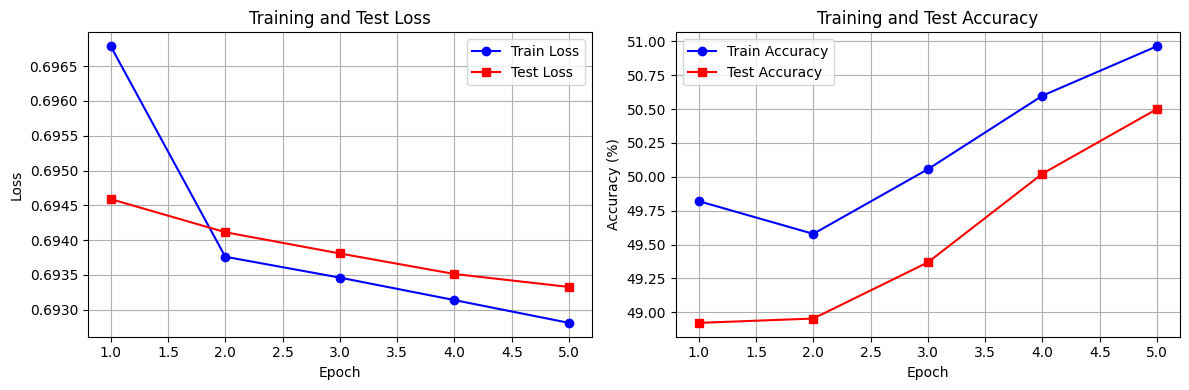


Final Test Loss: 0.693 - Final Test Acc: 50.50%


In [20]:
# Plot training curves
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-', label='Train Loss', marker='o')
plt.plot(range(1, num_epochs + 1), test_losses, 'r-', label='Test Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), [acc * 100 for acc in train_accuracies], 'b-', label='Train Accuracy', marker='o')
plt.plot(range(1, num_epochs + 1), [acc * 100 for acc in test_accuracies], 'r-', label='Test Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f'\nFinal Test Loss: {test_losses[-1]:.3f} - Final Test Acc: {test_accuracies[-1]*100:.2f}%')

Another advantage of Transformer-based models is that we can easily visualize the attention map for better understanding and interpreting how the model distributes its focus across different words

In [27]:
def visualize_attention(text, attention_weights, vocab, head_idx=0, max_words=30):
    """
    Visualize attention weights for a given text.
    
    Args:
        text: List of word indices (tensor or numpy array)
        attention_weights: Attention weights tensor [batch_size, num_heads, seq_len, seq_len]
        vocab: Vocabulary dictionary (reverse mapping: index -> word)
        head_idx: Which attention head to visualize (default: 0)
        max_words: Maximum number of words to display (default: 30)
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Convert tensor to numpy if needed
    if isinstance(text, torch.Tensor):
        text = text.cpu().numpy()
    if isinstance(attention_weights, torch.Tensor):
        attention_weights = attention_weights.cpu().detach().numpy()
    
    # Get attention weights for the first sample and specified head
    # attention_weights shape: [batch_size, num_heads, seq_len, seq_len]
    attn = attention_weights[0, head_idx]  # [seq_len, seq_len]
    
    # Find actual sequence length (exclude padding)
    seq_len = len([idx for idx in text if idx != 0])
    seq_len = min(seq_len, max_words)  # Limit display length
    
    # Extract relevant portion
    attn = attn[:seq_len, :seq_len]
    text = text[:seq_len]
    
    # Create reverse vocabulary mapping (index -> word)
    reverse_vocab = {v: k for k, v in vocab.items()}
    words = [reverse_vocab.get(int(idx), '<unk>') for idx in text]
    
    # Create figure
    plt.figure(figsize=(12, 10))
    
    # Plot attention heatmap
    sns.heatmap(attn, 
                xticklabels=words, 
                yticklabels=words,
                cmap='Blues',
                cbar=True,
                square=True,
                linewidths=0.5,
                fmt='.2f',
                annot=False)
    
    plt.title(f'Attention Map - Head {head_idx}', fontsize=14, fontweight='bold')
    plt.xlabel('Key (attended to)', fontsize=12)
    plt.ylabel('Query (attending from)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


We can also visualize different attention heads to see how each head focuses on different aspects of the text:


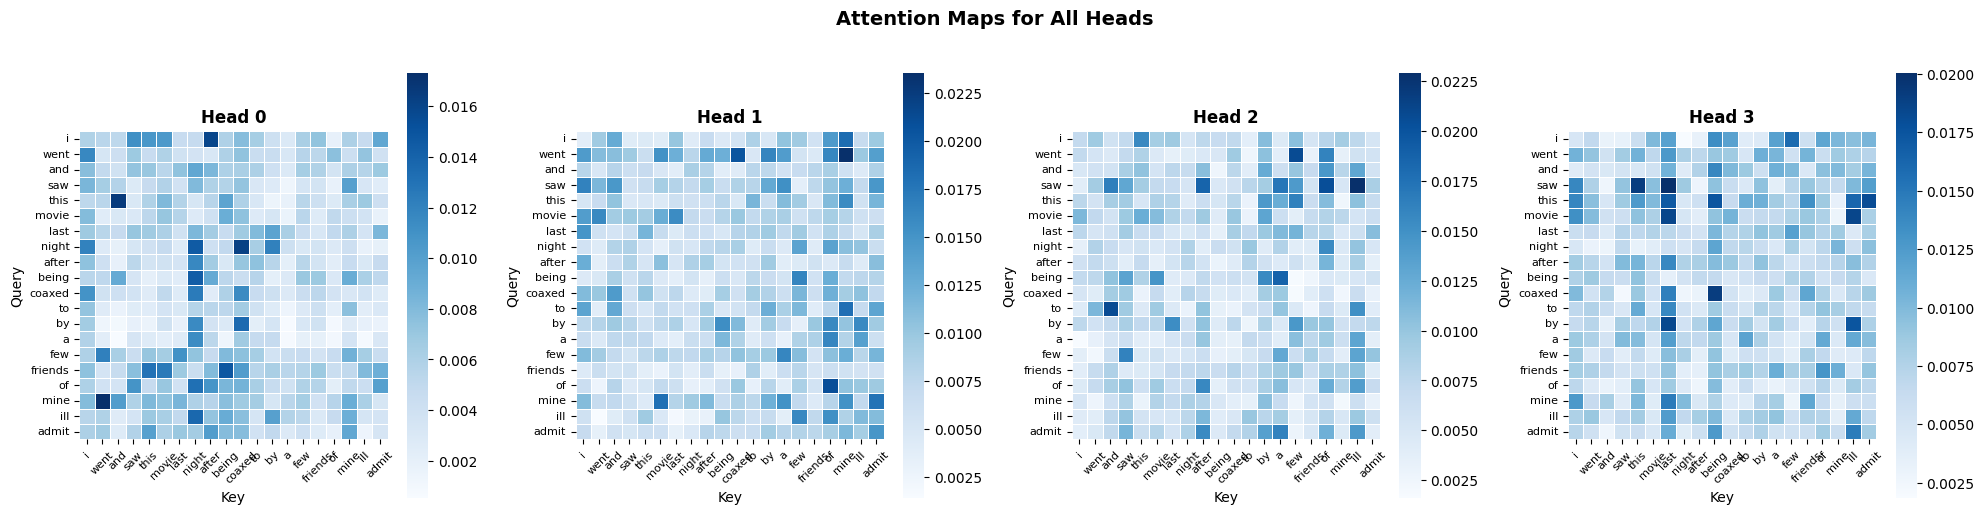

In [28]:
# Visualize all attention heads
import seaborn as sns

num_heads = attention_weights.shape[1]
fig, axes = plt.subplots(1, num_heads, figsize=(5*num_heads, 5))

# Convert tensor to numpy if needed
if isinstance(text_tensor[0], torch.Tensor):
    text_array = text_tensor[0].cpu().numpy()
else:
    text_array = text_tensor[0]

if isinstance(attention_weights, torch.Tensor):
    attn_np = attention_weights.cpu().detach().numpy()
else:
    attn_np = attention_weights

# Find actual sequence length (exclude padding)
seq_len = len([idx for idx in text_array if idx != 0])
seq_len = min(seq_len, 20)  # Limit display length

# Create reverse vocabulary mapping
reverse_vocab = {v: k for k, v in vocab.items()}
words = [reverse_vocab.get(int(idx), '<unk>') for idx in text_array[:seq_len]]

for head_idx in range(num_heads):
    attn = attn_np[0, head_idx][:seq_len, :seq_len]
    
    sns.heatmap(attn, 
                xticklabels=words, 
                yticklabels=words,
                cmap='Blues',
                cbar=True,
                square=True,
                ax=axes[head_idx] if num_heads > 1 else axes,
                linewidths=0.5,
                fmt='.2f',
                annot=False)
    
    title = f'Head {head_idx}'
    if num_heads > 1:
        axes[head_idx].set_title(title, fontsize=12, fontweight='bold')
        axes[head_idx].set_xlabel('Key', fontsize=10)
        axes[head_idx].set_ylabel('Query', fontsize=10)
        axes[head_idx].tick_params(axis='x', rotation=45, labelsize=8)
        axes[head_idx].tick_params(axis='y', rotation=0, labelsize=8)
    else:
        axes.set_title(title, fontsize=12, fontweight='bold')
        axes.set_xlabel('Key', fontsize=10)
        axes.set_ylabel('Query', fontsize=10)
        axes.tick_params(axis='x', rotation=45, labelsize=8)
        axes.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Attention Maps for All Heads', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Don't be surprised, the results are awful. There are lots of ways to improve what we have done here. Try to see if you can improve things.